In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import pycountry
import sys
import copy as cp
from random import randrange, randint
import ast
import geopy as gpy
import itertools
import time

import geopandas as gpd

from src.text_processing_functions import *
from src.LLM_functions import *
from src.plot_functions import *
from src.data import *
from src.post_process_functions import *

#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

In [11]:
###### FILE PATHS
#fig_path = '/home/lhasbini/como_school/figure/'
#file_path_save = '/scratchx/lhasbini/como_school/'
json_file = DATA_IN_JSONS +'filtered_report_types_nat_hazards_summary-header.json'

##### Open and read the JSON file
with open(json_file, 'r') as json_file:
    filtered_reports = json.load(json_file)

#### EXAMPLE OF LABELLED REPORTS
df_labelled = pd.read_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_laura.csv')
df_labelled = df_labelled.replace({np.nan: None})

df_labelled_luca = pd.read_csv(DATA_LABELLED+'labelled_reports_luca.csv')
df_labelled_luca = df_labelled_luca.replace({np.nan: None})

In [42]:
df_labelled.appealCode.nunique()

17

In [41]:
df_labelled_luca.appealCode.nunique()

8

In [12]:
# df_labelled.head(7)

In [22]:
# Convert the labelled examples to chat format
# df_labelled_chat = convert_labelled_chat_format(df_labelled)
# df_labelled_chat.to_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_chat-format_laura.csv', encoding='utf-8', index=False)
df_labelled_chat = pd.read_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_chat-format_laura.csv', encoding='utf-8')
df_labelled_chat = df_labelled_chat.replace({np.nan: None})

df_labelled_luca_chat = convert_labelled_chat_format(df_labelled_luca)
df_labelled_luca_chat.to_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_chat-format_luca.csv', encoding='utf-8', index=False)

In [14]:
df_labelled_luca_chat.head()

,Unnamed: 0,reportDate,hazardType,hazardSubtypes,country,region,city,locationAnnotation,startYear,startMonth,startDay,endYear,endMonth,endDay,hazardName,appealCode
0,0,2023-05-12,Flood,['flash flood'],Iraq,northern Kurdish,None,"After one of the driest years in decades, heav...",2021,12.0,17.0,None,None,None,None,MDRIQ014
1,0,2023-05-12,Flood,['flash flood'],Iraq,Erbil,None,The overnight rainfall caused a flash flood in...,2021,12.0,17.0,None,None,None,None,MDRIQ014
2,0,2023-05-12,Flood,['flash flood'],Iraq,Erbil,None,"In the early hours of the morning, muddy water...",2021,12.0,17.0,None,None,None,None,MDRIQ014
3,0,2023-05-12,Flood,['flash flood'],Iraq,Kirkuk,None,The overnight rainfall caused a flash flood in...,2021,12.0,17.0,None,None,None,None,MDRIQ014
4,0,2023-05-12,Flood,['flash flood'],Iraq,northern Iraq,None,The overnight rainfall caused a flash flood in...,2021,12.0,17.0,None,None,None,None,MDRIQ014


In [ ]:
# Add column for geocoding with ESRI
df_labelled_chat['address'] = df_labelled_chat[['country', 'region', 'city']].apply(lambda x: ', '.join(filter(None, x)), axis=1)

In [15]:
#df_labelled_chat.head(5)

In [16]:
# Add Geolocation and spatial information (region from cities)
from geopy.extra.rate_limiter import RateLimiter
from rapidfuzz.distance import Levenshtein

geolocator = gpy.geocoders.Nominatim(user_agent='orienternet')
# geocode = RateLimiter(geolocator.geocode, min_delay_seconds=20)

In [17]:
def rotated_levenshtein_similarity(str1, str2):
    """Compute the best Levenshtein similarity considering all rotations of words."""
    words1, words2 = str1.split(), str2.split()

    # Generate all possible word orderings (rotations) for comparison
    permutations1 = [" ".join(p) for p in itertools.permutations(words1)]
    permutations2 = [" ".join(p) for p in itertools.permutations(words2)]

    # Compute the max similarity considering all orderings
    max_similarity = max(Levenshtein.normalized_similarity(p1, p2) for p1 in permutations1 for p2 in permutations2)

    return max_similarity

In [27]:
list_admin_words = [
    "Regency", "Province", "State", "Department", "Region", "River",
    "Territory", "County", "District", "Municipality", "Prefecture", 
    "Canton", "Commune", "Borough", "Parish", "Metropolitan Area", 
    "Subregion", "Zone", "Subdivision", "Ward", "Township", "City", 
    "Village", "Hamlet", "Municipality", "Governorate", "Autonomous Region",
    "County Borough", "Council Area", "Federal District", "Locality"
]
def remove_admin_words(location_str) :
    for word in list_admin_words:
        location_str = location_str.replace(word, "").strip()
    return location_str

In [28]:
def geocoding_labelled_reports(df_labelled_chat) :
    df_labelled_chat_geo = pd.DataFrame(columns=df_labelled_chat.columns.tolist()+['latitude', 'longitude'])
    for index, row in df_labelled_chat.iterrows():
        country = row["country"]
        if row.city:
            finest_loc_id = "city"
            finest_loc_vals = row.city
        elif row.region:
            finest_loc_id = "region"
            finest_loc_vals = row.region
        else:
            finest_loc_id = None
            print("No location information for response: ", response_row.appealCode)
        # print(finest_loc_id)
        # print(row)
        if finest_loc_id:
            # nominatim_query = {
            #     "country": country,
            #     finest_loc_id: finest_loc_vals
            # }
            time_last_request = time.time()
            nominatim_query=finest_loc_vals+", "+country

            time_new_request = time.time()
            if time_new_request - time_last_request < 1:
                time.sleep(1)#time_new_request - time_last_request)
            nominatim_result = geolocator.geocode(nominatim_query, exactly_one=True, language="en")
            time_last_request = time_new_request
            if nominatim_result is None:
                print("No results for query: ", nominatim_query)
            else:
                ## Double check that the known information is similar to the one found
                # similarity = Levenshtein.normalized_similarity(finest_loc_vals, nominatim_result.raw['name'])
                finest_loc_vals_cleaned = remove_admin_words(finest_loc_vals)
                nominatim_result_cleaned = remove_admin_words(nominatim_result.raw['name'])
                similarity = rotated_levenshtein_similarity(finest_loc_vals_cleaned, nominatim_result_cleaned)

                if similarity > 0.5 :
                    print("CORRECT location "+nominatim_result.raw['name']+" for "+finest_loc_vals+", similarity = "+str(similarity))
                    row["latitude"] = nominatim_result.latitude
                    row["longitude"] = nominatim_result.longitude
                    row[finest_loc_id] = nominatim_result.raw['name']

                    #Find in case the location is a city
                    if finest_loc_id== "city" :
                        #Reverse geocoding to get region/state name
                        location_details = geolocator.reverse((nominatim_result.latitude, nominatim_result.longitude), exactly_one=True, addressdetails=True)
                        address = location_details.raw.get("address", {})
                        region = address.get("region")
                        if region is None :
                            region = address.get("state")
                        row["region"] = region

                    #Add the row to the DataFrame with geocoding
                    df_labelled_chat_geo = pd.concat([df_labelled_chat_geo, row.to_frame().T], ignore_index=True)
                else :
                    print("WRONG location "+nominatim_result.raw['name']+" for "+finest_loc_vals+", similarity = "+str(similarity))
    return df_labelled_chat_geo

In [29]:
df_labelled_chat_geo = geocoding_labelled_reports(df_labelled_chat)

CORRECT location Tamana for Tamana, similarity = 1.0
CORRECT location Tamana for Tamana, similarity = 1.0
CORRECT location Arorae for Arorae, similarity = 1.0
CORRECT location Onotoa for Onotoa, similarity = 1.0
CORRECT location Nonouti for Nonouti, similarity = 1.0
CORRECT location Tamana for Tamana, similarity = 1.0
CORRECT location Arorae for Arorae, similarity = 1.0
CORRECT location Onotoa for Onotoa, similarity = 1.0
CORRECT location Nonouti for Nonouti, similarity = 1.0
CORRECT location Tarawa for Tarawa, similarity = 1.0
CORRECT location Port Moresby for Port Moresby, similarity = 1.0
CORRECT location Port Moresby for Port Moresby, similarity = 1.0
CORRECT location Port Moresby for Port Moresby, similarity = 1.0
CORRECT location Port Moresby for Port Moresby, similarity = 1.0
CORRECT location Temotu for Temotu, similarity = 1.0
CORRECT location Malaita for Malaita, similarity = 1.0
CORRECT location Temotu for Temotu, similarity = 1.0
CORRECT location Malaita for Malaita, similar

In [31]:
df_labelled_luca_chat_geo = geocoding_labelled_reports(df_labelled_luca_chat)

No results for query:  northern Kurdish, Iraq
CORRECT location Erbil for Erbil, similarity = 1.0
CORRECT location Erbil for Erbil, similarity = 1.0
CORRECT location Kirkuk for Kirkuk, similarity = 1.0
No results for query:  northern Iraq, Iraq
CORRECT location Daratu for Daratu, similarity = 1.0
CORRECT location Qushtapa for Qushtapa, similarity = 1.0
CORRECT location Shamamk for Shamamk, similarity = 1.0
CORRECT location Zhyan for Zhyan, similarity = 1.0
No results for query:  Roshinbiri, Iraq
WRONG location bahrka-bahar for Bahrka, similarity = 0.41666666666666663
CORRECT location Vientiane Capital for Vientiane Capital, similarity = 1.0
CORRECT location Bokeo Province for Bokeo, similarity = 1.0
CORRECT location Houaphanh for Houaphan, similarity = 0.8888888888888888
CORRECT location Luang Prabang for Luang Prabang, similarity = 1.0
CORRECT location Sainyabuli Province for Xaignabouli, similarity = 0.6363636363636364
CORRECT location Xiangkhouang Province for Xiangkhouang, similarit

In [40]:
df_labelled_chat_geo.to_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_chat-format_geocoding_laura.csv', encoding='utf-8', index=False)
# df_labelled_luca_chat_geo.to_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_chat-format_geocoding_luca.csv', encoding='utf-8', index=False)

In [30]:
len(df_labelled_chat_geo)/len(df_labelled_chat)

0.8395522388059702

In [33]:
len(df_labelled_luca_chat_geo)/len(df_labelled_luca_chat)

0.7521367521367521

In [36]:
df_labelled_chat_geo.head()

,hazardType,hazardSubtypes,country,region,city,locationAnnotation,startYear,startMonth,startDay,endYear,endMonth,endDay,hazardName,appealCode,Country,reportDate,latitude,longitude
0,Storm,tropical storm,Kiribati,Tamana,None,The Vanuatu Red Cross Society (VRCS) has mobil...,None,None,None,None,None,None,Pam,MDR55001,KIR,15/05/2015,-2.5,175.982483
1,Storm,tropical storm,Kiribati,Tamana,None,"The four outer atolls of Tamana, Arorae, Onoto...",None,None,None,None,None,None,Pam,MDR55001,KIR,15/05/2015,-2.5,175.982483
2,Storm,tropical storm,Kiribati,Arorae,None,"The four outer atolls of Tamana, Arorae, Onoto...",None,None,None,None,None,None,Pam,MDR55001,KIR,15/05/2015,-2.643279,176.819152
3,Storm,tropical storm,Kiribati,Onotoa,None,"The four outer atolls of Tamana, Arorae, Onoto...",None,None,None,None,None,None,Pam,MDR55001,KIR,15/05/2015,-1.828767,175.54559
4,Storm,tropical storm,Kiribati,Nonouti,None,"The four outer atolls of Tamana, Arorae, Onoto...",None,None,None,None,None,None,Pam,MDR55001,KIR,15/05/2015,-0.723089,174.431603


In [34]:
df_labelled_luca_chat_geo.head(3)

,Unnamed: 0,reportDate,hazardType,hazardSubtypes,country,region,city,locationAnnotation,startYear,startMonth,startDay,endYear,endMonth,endDay,hazardName,appealCode,latitude,longitude
0,0,2023-05-12,Flood,['flash flood'],Iraq,Erbil,None,The overnight rainfall caused a flash flood in...,2021,12.0,17.0,None,None,None,None,MDRIQ014,36.191174,44.009414
1,0,2023-05-12,Flood,['flash flood'],Iraq,Erbil,None,"In the early hours of the morning, muddy water...",2021,12.0,17.0,None,None,None,None,MDRIQ014,36.191174,44.009414
2,0,2023-05-12,Flood,['flash flood'],Iraq,Kirkuk,None,The overnight rainfall caused a flash flood in...,2021,12.0,17.0,None,None,None,None,MDRIQ014,35.471931,44.39539


## Plot for a report with multi-hazard

In [73]:
appeal_test = "MDRUG050"
df_labelled_test = df_labelled_chat.loc[df_labelled_chat.appealCode == appeal_test]
df_labelled_test_geo = geocoding_labelled_reports(df_labelled_test)

WRONG location Islamic University in Uganda, Main Campus;Islamic University of Uganda for eastern, similarity = 0.08571428571428574
CORRECT location Mbale for Mbale, similarity = 1.0
CORRECT location Kapchorwa for Kapchorwa, similarity = 1.0
CORRECT location Bulambuli for Bulambuli, similarity = 1.0
CORRECT location Bukedea for Bukedea, similarity = 1.0
CORRECT location Butaleja for Butaleja, similarity = 1.0
CORRECT location Sironko for Sironko, similarity = 1.0
CORRECT location Bududa for Bududa, similarity = 1.0
CORRECT location Namisindwa for Namisindwa, similarity = 1.0
CORRECT location Ntoroko for Ntoroko, similarity = 1.0
CORRECT location Mbale for Mbale, similarity = 1.0
CORRECT location Kapchorwa for Kapchorwa, similarity = 1.0
CORRECT location Bulambuli for Bulambuli, similarity = 1.0
CORRECT location Bukedea for Bukedea, similarity = 1.0
CORRECT location Butaleja for Butaleja, similarity = 1.0
CORRECT location Sironko for Sironko, similarity = 1.0
CORRECT location Bududa for

In [86]:
df_labelled_test.head(5)

,hazardType,hazardSubtypes,country,region,city,locationAnnotation,startYear,startMonth,startDay,endYear,endMonth,endDay,hazardName,appealCode,Country,reportDate
117,Flood,None,Uganda,eastern,None,"In April 2024, the Eastern Uganda-Elgon region...",2024.0,4.0,None,2024.0,None,None,None,MDRUG050,UGA,30/08/2024
118,Flood,None,Uganda,None,Mbale,This resulted in significant impacts from epis...,2024.0,4.0,None,2024.0,None,None,None,MDRUG050,UGA,30/08/2024
119,Flood,None,Uganda,None,Kapchorwa,This resulted in significant impacts from epis...,2024.0,4.0,None,2024.0,None,None,None,MDRUG050,UGA,30/08/2024
120,Flood,None,Uganda,None,Bulambuli,This resulted in significant impacts from epis...,2024.0,4.0,None,2024.0,None,None,None,MDRUG050,UGA,30/08/2024
121,Flood,None,Uganda,None,Bukedea,This resulted in significant impacts from epis...,2024.0,4.0,None,2024.0,None,None,None,MDRUG050,UGA,30/08/2024


In [74]:
df_labelled_test_geo.columns

Index(['hazardType', 'hazardSubtypes', 'country', 'region', 'city',
       'locationAnnotation', 'startYear', 'startMonth', 'startDay', 'endYear',
       'endMonth', 'endDay', 'hazardName', 'appealCode', 'Country',
       'reportDate', 'latitude', 'longitude'],
      dtype='object')

In [79]:
df_all_locs = {}
for hazard in df_labelled_test_geo.hazardType.unique() : 
    df_labelled_test_geo_haz = df_labelled_test_geo.loc[df_labelled_test_geo.hazardType == hazard]
    df_all_locs[hazard] = gpd.GeoDataFrame(df_labelled_test_geo_haz, geometry=gpd.points_from_xy(df_labelled_test_geo_haz.longitude, df_labelled_test_geo_haz.latitude))

In [81]:
df_all_locs.keys()

dict_keys(['Flood', 'Storm', 'Mass movement'])

In [106]:
dict_color = {"Flood" : "blue", "Storm" : "purple", "Mass movement" : "brown"}
dict_marker = {
    "Flood": "o",         # Circle
    "Earthquake": "s",    # Square
    "Mass movement": "^",     # Triangle
    "Storm": "*",         # Diamond
    "Drought": "p",       # Pentagon
    "Wildfire": "v",      # Star
}

In [107]:
def add_jitter(coords, scale=0.05):
    return coords + np.random.uniform(-scale, scale, size=coords.shape)

/tmp/ipykernel_446355/2251173517.py:2: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


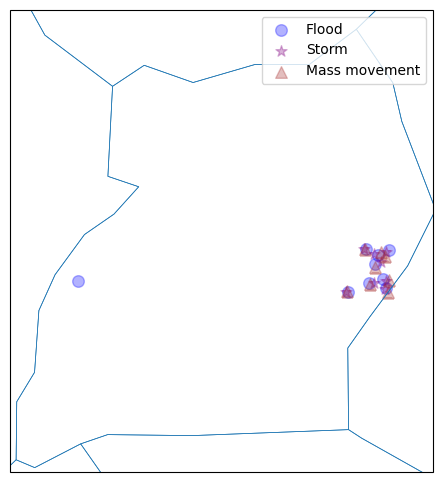

In [116]:
f, axes = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.PlateCarree()),figsize=(6, 6))
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world.boundary.plot(ax=axes, linewidth=0.5)
for hazard in df_all_locs.keys() : 
    # df_all_locs[hazard].plot(ax=axes, color=dict_color[hazard], markersize=50, alpha=0.4)
    marker = dict_marker.get(hazard, "o")  # Default to circle if not in dictionary

    x_values = add_jitter(df_all_locs[hazard].geometry.x)
    y_values = add_jitter(df_all_locs[hazard].geometry.y)
    
    axes.scatter(
        x_values, y_values, 
        color=dict_color[hazard], 
        marker=marker, 
        s=70, alpha=0.3, label=hazard
    )

# Set the focus on Uganda
axes.set_xlim([29.5, 35])  # Longitude limits
axes.set_ylim([-1.5, 4.5])  # Latitude limits
axes.legend(fontsize=10)

plt.show()